In [20]:
## Tools

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [21]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2 ,max_results= 5, doc_content_chars_max=1000)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description="Query Arxiv Papers")
print(arxiv.name)

arxiv


In [22]:
arxiv.invoke("Agriculture")

'Published: 2025-06-11\nTitle: One For All: LLM-based Heterogeneous Mission Planning in Precision Agriculture\nAuthors: Marcos Abel Zuzuárregui, Mustafa Melih Toslak, Stefano Carpin\nSummary: Artificial intelligence is transforming precision agriculture, offering farmers new tools to streamline their daily operations. While these technological advances promise increased efficiency, they often introduce additional complexity and steep learning curves that are particularly challenging for non-technical users who must balance tech adoption with existing workloads. In this paper, we present a natural language (NL) robotic mission planner that enables non-specialists to control heterogeneous robots through a common interface. By leveraging large language models (LLMs) and predefined primitives, our architecture seamlessly translates human language into intermediate descriptions that can be executed by different robotic platforms. With this system, users can formulate complex agricultural mi

In [23]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=1000)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
wiki.name

'wikipedia'

In [24]:
from dotenv import load_dotenv
load_dotenv()

import os 

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [25]:
### Tavily Search Tool 
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [26]:
tavily.invoke("What is the latest research on quantum computing?")

[{'title': 'New MIT report captures state of quantum computing',
  'url': 'https://mitsloan.mit.edu/ideas-made-to-matter/new-mit-report-captures-state-quantum-computing',
  'content': 'By\n\nQuantum computing is evolving into a tangible technology that holds significant business and commercial promise, although the exact timing of when it will impact those areas remains unclear, according to a new report led by researchers at the MIT Initiative on the Digital Economy.\n\nThe “Quantum Index Report 2025” charts the technology’s momentum, with a comprehensive, data-driven assessment of the state of quantum technologies.\n\nThe inaugural report aims to make quantum computing and networking technologies more accessible to entrepreneurs, investors, teachers, and business decision makers — all of whom will play a critical role in how quantum computing is developed, commercialized, and governed. [...] Businesses are buzzing over quantum computing. The report tracks how often the technology was

In [27]:
# Combine all the tools 
tools = [arxiv, wiki,tavily]

In [29]:
# Initialize the LLM Model
from langchain_groq import ChatGroq

llm =ChatGroq(model="qwen/qwen3-32b")

In [30]:
llm.invoke("What is AI?")

AIMessage(content='<think>\nOkay, the user asked, "What is AI?" I need to explain AI in a way that\'s clear and not too technical. Let me start with the basics. AI stands for Artificial Intelligence, right? It\'s about creating machines or software that can do tasks that usually require human intelligence. Examples like problem-solving, learning, understanding language, maybe even recognizing patterns.\n\nWait, maybe I should break it down. First, define AI. Then mention key concepts like machine learning and deep learning. But I need to make sure these terms are explained in simple terms. Machine learning is a subset of AI where systems learn from data, so they improve over time without being programmed. Deep learning uses neural networks with many layers to model complex patterns. Examples could include image recognition or natural language processing.\n\nAlso, there\'s different types of AI – narrow AI, which is focused on specific tasks (like Siri or recommendation systems), and ge

In [32]:
llm_with_tools = llm.bind_tools(tools= tools)

In [33]:
llm_with_tools.invoke("What is the latest news on AI?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the latest news on AI. I need to figure out which tool to use here. Let me check the available functions.\n\nFirst, there\'s the arxiv function, which is for querying academic papers. But the user is asking about news, not research papers. So probably not the best fit.\n\nNext, the wikipedia function. Wikipedia does have information on AI, but it\'s more of a general knowledge source. The latest news might not be there because Wikipedia entries are more about established facts and history, not current events.\n\nThen there\'s the tavily_search_results_json function, which is described as a search engine optimized for current events. That sounds exactly like what\'s needed here. The user wants the latest news, so using this search function makes sense.\n\nSo I\'ll use tavily_search_results_json with the query "latest news on AI". That should fetch the most recent and relevant news articles about 

## Workflow

In [35]:
## State Schema 
from typing_extensions import TypedDict # Entire State that we are creating 
from langchain_core.messages import AnyMessage # Human or AI Messages
from typing import Annotated # Annotations or labelling 
from langgraph.graph.message import add_messages #Reducers in langgraph

In [39]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


In [42]:
#Entire Chatbot With Langgraph
from IPython.display import Image,display
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [54]:
# Node Definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest messages (result) from assistant is a tool call -> tools_condition routes to the tools 
    # If the latest messages (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition)
builder.add_edge("tools",tools)

# Compile 
graph = builder.compile()

#View
display(Image(graph.get_graph().draw_mermaid_png()))


TypeError: unhashable type: 'list'

In [55]:
messages = graph.invoke({"messages":"1706.03762"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (w7p4254yr)
 Call ID: w7p4254yr
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models

In [51]:
messages = graph.invoke({"messages":"Hii!! My Name is Piyush"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hii!! My Name is Piyush
================================== Ai Message ==================================

Hello Piyush! How can I help you today?


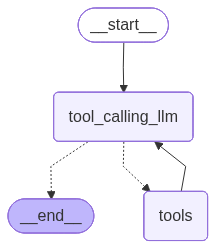

In [56]:
# Node Definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest messages (result) from assistant is a tool call -> tools_condition routes to the tools 
    # If the latest messages (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition)
builder.add_edge("tools","tool_calling_llm")

# Compile 
graph = builder.compile()

#View
display(Image(graph.get_graph().draw_mermaid_png()))


In [58]:
messages = graph.invoke({"messages":"What is the recent new on AI and then please tell me latest research paper on quantum mechanics"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent new on AI and then please tell me latest research paper on quantum mechanics
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (kx31a2e2z)
 Call ID: kx31a2e2z
  Args:
    query: recent advancements in AI 2024
  arxiv (gwsxzpchk)
 Call ID: gwsxzpchk
  Args:
    query: latest research in quantum mechanics
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The 7 Most Groundbreaking AI Breakthroughs of 2024 That Are ...", "url": "https://www.brainforge.ai/blog/the-7-most-groundbreaking-ai-breakthroughs-of-2024-that-are-reshaping-our-future", "content": "In May 2024, OpenAI's GPT-4o marked a pivotal moment in artificial intelligence by seamlessly combining text, vision, and audio processing capabilities in a single model. This breakthrough, along

In [59]:
messages = graph.invoke({"messages":"kaisa hai laude"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

kaisa hai laude
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (rn7nacan9)
 Call ID: rn7nacan9
  Args:
    query: kaisa hai laude meaning and context
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "हिंदी<अंग्रेज़ी हिंदी में \"लाउडे\" का क्या मतलब होता है?? : r/translator - Reddit", "url": "https://www.reddit.com/r/translator/comments/134fmdc/hindienglish_what_does_laude_mean_in_hindi/?tl=hi", "content": "Translations active   Show original\n\n## Thanks for the feedback!\n\nTell us more about why this content is not helpful.\n\nGo to translator   \n\nr/translator   • \n\n[deleted]\n\n# हिंदी<अंग्रेज़ी हिंदी में \"लाउडे\" का क्या मतलब होता है??\n\nमेरे एक सहकर्मी हैं जो भारत से वीज़ा पर हैं और वह हिंदी बोलते हैं, दोस्त हमेशा मुझे लाउडे/लौडे (मुझे ठीक से या

In [60]:
messages = graph.invoke({"messages":"Give me some details about linked list in java"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me some details about linked list in java
================================== Ai Message ==================================

A **linked list** in Java is a linear data structure where elements (called nodes) are stored in non-contiguous memory locations. Each node contains:
1. **Data** (the value stored)
2. **Reference(s)** (pointer to the next node, and optionally the previous node in a doubly linked list).

Java’s `java.util.LinkedList` class implements this structure as a **doubly linked list**, meaning each node points to both the next and previous nodes. Here’s a breakdown:

---

### **Key Features**
- **Dynamic Size**: Grows/shrinks as needed.
- **Efficient Insertions/Deletions**: Fast at the beginning and middle (O(1) for known nodes, O(n) for traversal to find a node).
- **No Random Access**: Accessing elements requires traversal (O(n) time).

---

### **Common Operations**
| Operation        